# CAM / CLM equilibrium checks by case - CTRL_FUT

Reusable functions live in `equilibrium.py`. Run in order: **load a case → load/select modified cells → calculate → plot**. This notebook has no precomputed model results. See `README.md` for assumptions, units, and interpretation.

A 10-year simulatiomns cannot support a 20-year rolling derivative. For fixed SST runs, a steady nonzero radiation imbalance can coexist with a statistically steady atmosphere. Gas stationarity must be interpreted against the imposed boundary conditions.

In [1]:
CASE = 'NF2100ssp585norbc_tropstratchem_nudg_ctrl_f19_f19-20260925'
ROLL_YEARS = 3
GAS_BASIS = {gas: None for gas in eq.GASES}  # Verify each tracer, then use 'dry' or 'moist'.
GAS_BASIS['CH4'] = 'dry'

## 1. Configuration and imports

In [52]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from IPython.display import display
import equilibrium as eq

ARCHIVE = Path('/cluster/home/adelez/nird/BRL-FRST-XPSN_archive')
CASE_DIR = ARCHIVE / CASE
RUN_CLM, RUN_CAM = True, True
YEARS = (2000, 2009)  # None for all years; supports model year 0001
CLM_REGIONS = ('modified',)
CAM_REGIONS = ('global', 'north45', 'modified')
TIMESTAMP = 'bounds'  # No bounds? Inspect first, then choose 'start', 'end', or 'mid'.
SOIL_DEPTH_M = 1.0
DEPTH_OVERRIDES = {}  # e.g. {'levgrnd': verified_depths_in_metres}; never use indices
PRESSURE_HPA = (1000, 850, 700, 500, 300, 200, 100, 70, 50, 30, 10, 5, 1)
MASK_FILE = Path('lcc-modified-cells/modified_cells.nc')
BASE_SURFDATA = Path('/cluster/shared/noresm/inputdata/lnd/clm2/surfdata_map/release-clm5.0.18/surfdata_1.9x2.5_hist_78pfts_CMIP6_simyr2000_c190304.nc')
LCC_SURFDATA = Path('/cluster/shared/noresm/inputdata/lnd/clm2/surfdata_map/surfdata_1.9x2.5_SSP5-8.5_2100_78pfts_LPJGUESS.nc')
OUTPUT = Path('equilibrium_outputs') / CASE
OUTPUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})

## 2. Load dataset headers and inspect available fields
Full data are streamed one file at a time later. Annual-average files are not accepted by this monthly workflow.

In [53]:
FILES = {}
for component, enabled in [('CLM', RUN_CLM), ('CAM', RUN_CAM)]:
    if not enabled:
        continue
    FILES[component] = eq.history_files(CASE_DIR, component)
    print(component, len(FILES[component]), 'files; first:', FILES[component][0].name)
    requested = eq.CLM_VARS if component == 'CLM' else eq.CAM_VARS + eq.GASES + ('PS', 'P0', 'Q', 'hyai', 'hybi', 'hyam', 'hybm')
    with xr.open_dataset(FILES[component][0]) as header:
        display(pd.DataFrame([{'variable': v, 'dims': str(header[v].dims), 'units': header[v].attrs.get('units', ''),
                               'description': header[v].attrs.get('long_name', '')} for v in requested if v in header]))
        print('Missing in first file:', [v for v in requested if v not in header])
        for coordinate in ('levsoi', 'levgrnd'):
            if coordinate in header:
                print()
                #print(coordinate, header[coordinate].values, header[coordinate].attrs)

CLM 120 files; first: NF2100ssp585norbc_tropstratchem_nudg_ctrl_f19_f19-20260925.clm2.h0.2000-01.nc


,variable,dims,units,description
0,GPP,"('time', 'lat', 'lon')",gC/m^2/s,gross primary production
1,TOTVEGC,"('time', 'lat', 'lon')",gC/m^2,"total vegetation carbon, excluding cpool"
2,TOTVEGN,"('time', 'lat', 'lon')",gN/m^2,total vegetation nitrogen
3,TWS,"('time', 'lat', 'lon')",mm,total water storage
4,H2OSOI,"('time', 'levsoi', 'lat', 'lon')",mm3/mm3,volumetric soil water (vegetated landunits only)
5,TSOI,"('time', 'levgrnd', 'lat', 'lon')",K,soil temperature (vegetated landunits only)


Missing in first file: []

CAM 120 files; first: NF2100ssp585norbc_tropstratchem_nudg_ctrl_f19_f19-20260925.cam.h0.2000-01.nc


,variable,dims,units,description
0,TREFHT,"('time', 'lat', 'lon')",K,Reference height temperature
1,FSNT,"('time', 'lat', 'lon')",W/m2,Net solar flux at top of model
2,FLNT,"('time', 'lat', 'lon')",W/m2,Net longwave flux at top of model
3,TS,"('time', 'lat', 'lon')",K,Surface temperature (radiative)
4,CH4,"('time', 'lev', 'lat', 'lon')",mol/mol,CH4 concentration
5,PS,"('time', 'lat', 'lon')",Pa,Surface pressure
6,P0,(),Pa,reference pressure
7,Q,"('time', 'lev', 'lat', 'lon')",kg/kg,Specific humidity
8,hyai,"('ilev',)",,hybrid A coefficient at layer interfaces
9,hybi,"('ilev',)",,hybrid B coefficient at layer interfaces


Missing in first file: ['RESTOM', 'SF6', 'CFC115', 'N2O', 'CO2']


## 3. Build once, then load the modified-cell file
The first run compares the two surface files. Subsequent runs only load the cache. The matching CSV prints every selected cell with coordinates and PFT change. It is the mask for this surface-file pair, not for arbitrary future modifications.

In [54]:
needs_mask = (RUN_CLM and 'modified' in CLM_REGIONS) or (RUN_CAM and 'modified' in CAM_REGIONS)
cache = None
if needs_mask:
    if not MASK_FILE.exists():
        eq.build_modified_cells(BASE_SURFDATA, LCC_SURFDATA, MASK_FILE)
    cache = eq.load_modified_cells(MASK_FILE)
    #display(cache.attrs)
    if MASK_FILE.with_suffix('.csv').exists():
        cells = pd.read_csv(MASK_FILE.with_suffix('.csv'))
        #display(cells.head(10))
        print('Complete cell list:', MASK_FILE.with_suffix('.csv').resolve())
    for component, files in FILES.items():
        with xr.open_dataset(files[0]) as header:
            selected = eq.modified_mask(header, cache)
            print(component, int(selected.sum()), 'matching cells')

Modified cells: 1161; source: /cluster/shared/noresm/inputdata/lnd/clm2/surfdata_map/surfdata_1.9x2.5_SSP5-8.5_2100_78pfts_LPJGUESS.nc
Complete cell list: /cluster/home/adelez/BOREAL-FOREST-EXPANSION/diagnostics/equilibrium_tools/lcc-modified-cells/modified_cells.csv
CLM 1161 matching cells
CAM 1161 matching cells


## 4. CLM monthly time series and rolling derivatives
Area × land fraction weighting; soil fields at the saved level nearest 1 m. Missing variables stay unavailable. Derivatives are displayed only where enough consecutive complete years exist.

In [55]:
from pathlib import Path

# For invalid area cell (where landfranc == 0)
# Retain the original function so this cell can be rerun safely.
if not hasattr(eq, '_original_spatial_weights'):
    eq._original_spatial_weights = eq.spatial_weights

def clm_safe_spatial_weights(ds, component, region, cache=None):
    if component == 'CLM' and 'area' in ds and 'landfrac' in ds:
        area, fraction = ds.area, ds.landfrac

        # Missing land fractions are accepted only where area is also missing.
        if bool((fraction.isnull() & area.notnull()).any()):
            raise ValueError('Missing landfrac where area is present; inspect these cells.')

        inactive = fraction.isnull() | (fraction == 0)
        bad_area = ~np.isfinite(area) | (area <= 0)

        # The positive placeholder only satisfies area validation.
        # These cells receive exactly zero weight through landfrac.
        clean_area = area.where(~(inactive & bad_area), 1.0)
        clean_fraction = fraction.fillna(0)
        clean_area.attrs = area.attrs.copy()
        clean_fraction.attrs = fraction.attrs.copy()
        ds = ds.assign(area=clean_area, landfrac=clean_fraction)

    return eq._original_spatial_weights(ds, component, region, cache)

eq.spatial_weights = clm_safe_spatial_weights

# use its first 20 levels for soil water
with xr.open_dataset(clm_files[0], decode_times=False) as ds:
    DEPTH_OVERRIDES['levsoi'] = ds.levgrnd.values[:ds.sizes['levsoi']].copy()

print('Soil-water depths (m):', DEPTH_OVERRIDES['levsoi'])

Soil-water depths (m): [0.01 0.04 0.09 0.16 0.26 0.4  0.58 0.8  1.06 1.36 1.7  2.08 2.5  2.99
 3.58 4.27 5.06 5.95 6.94 8.03]


Excluded 1 record(s) with non-monthly bounds.
Selected depths (m): {'H2OSOI': 1.06, 'TSOI': 1.06}


,variable,note


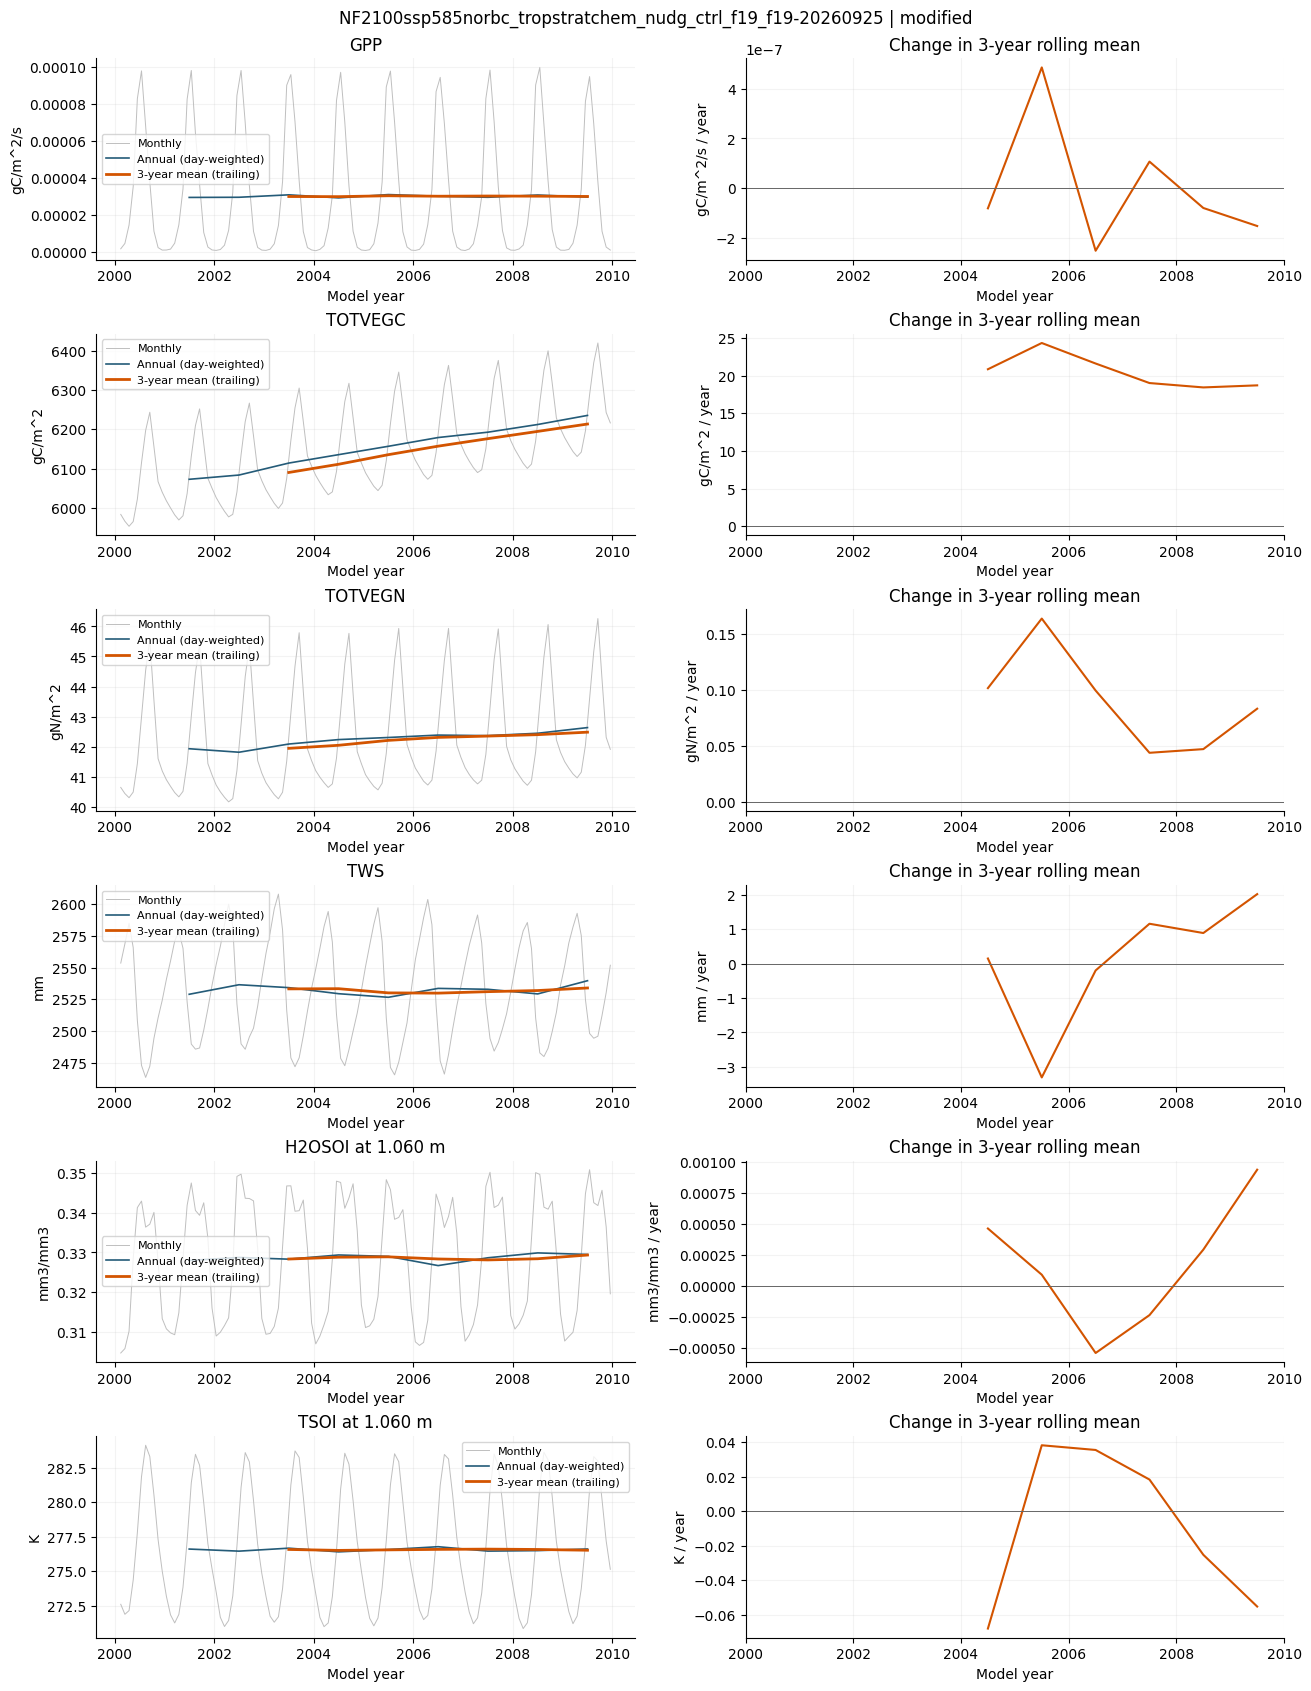

In [57]:
#excludes the January record with the extra 30 minutes

if RUN_CLM:
    directory = Path(OUTPUT / 'CLM'); directory.mkdir(parents=True, exist_ok=True)
    bad_file = 'NF2100ssp585norbc_tropstratchem_nudg_ctrl_f19_f19-20260925.clm2.h0.2000-01.nc'
    clm_files = [file for file in FILES['CLM'] if Path(file).name != bad_file]
    print(f'Excluded {len(FILES["CLM"]) - len(clm_files)} record(s) with non-monthly bounds.')

    clm = eq.read_case(clm_files, 'CLM', regions=CLM_REGIONS, cache=cache, years=YEARS,
                       soil_depth=SOIL_DEPTH_M, depth_overrides=DEPTH_OVERRIDES, timestamp=TIMESTAMP)
    print('Selected depths (m):', clm['depths'])
    display(clm['audit'])
    #eq.save_result(clm, OUTPUT / 'CLM')

    for region in CLM_REGIONS:
        fig, summary = eq.plot_timeseries(clm, eq.CLM_VARS, region, CASE, window=ROLL_YEARS)
        fig.savefig(OUTPUT / 'CLM' / f'{region}_timeseries.png', dpi=160)
        #summary.to_csv(OUTPUT / 'CLM' / f'{region}_summary.csv', index=False)
        #display(summary)
        plt.show()

## 5. CAM surface/radiation time series
Global gas diagnostics are primary. Regional selections supplement them. CAM uses full grid-cell area, including the atmospheric column above coastal cells; it is not land-fraction weighted. RESTOM is derived as FSNT − FLNT if absent (top of model).

,variable,note
0,CFC115,missing
1,CH4,monthly-mean product approximation
2,CO2,missing
3,N2O,missing
4,SF6,missing


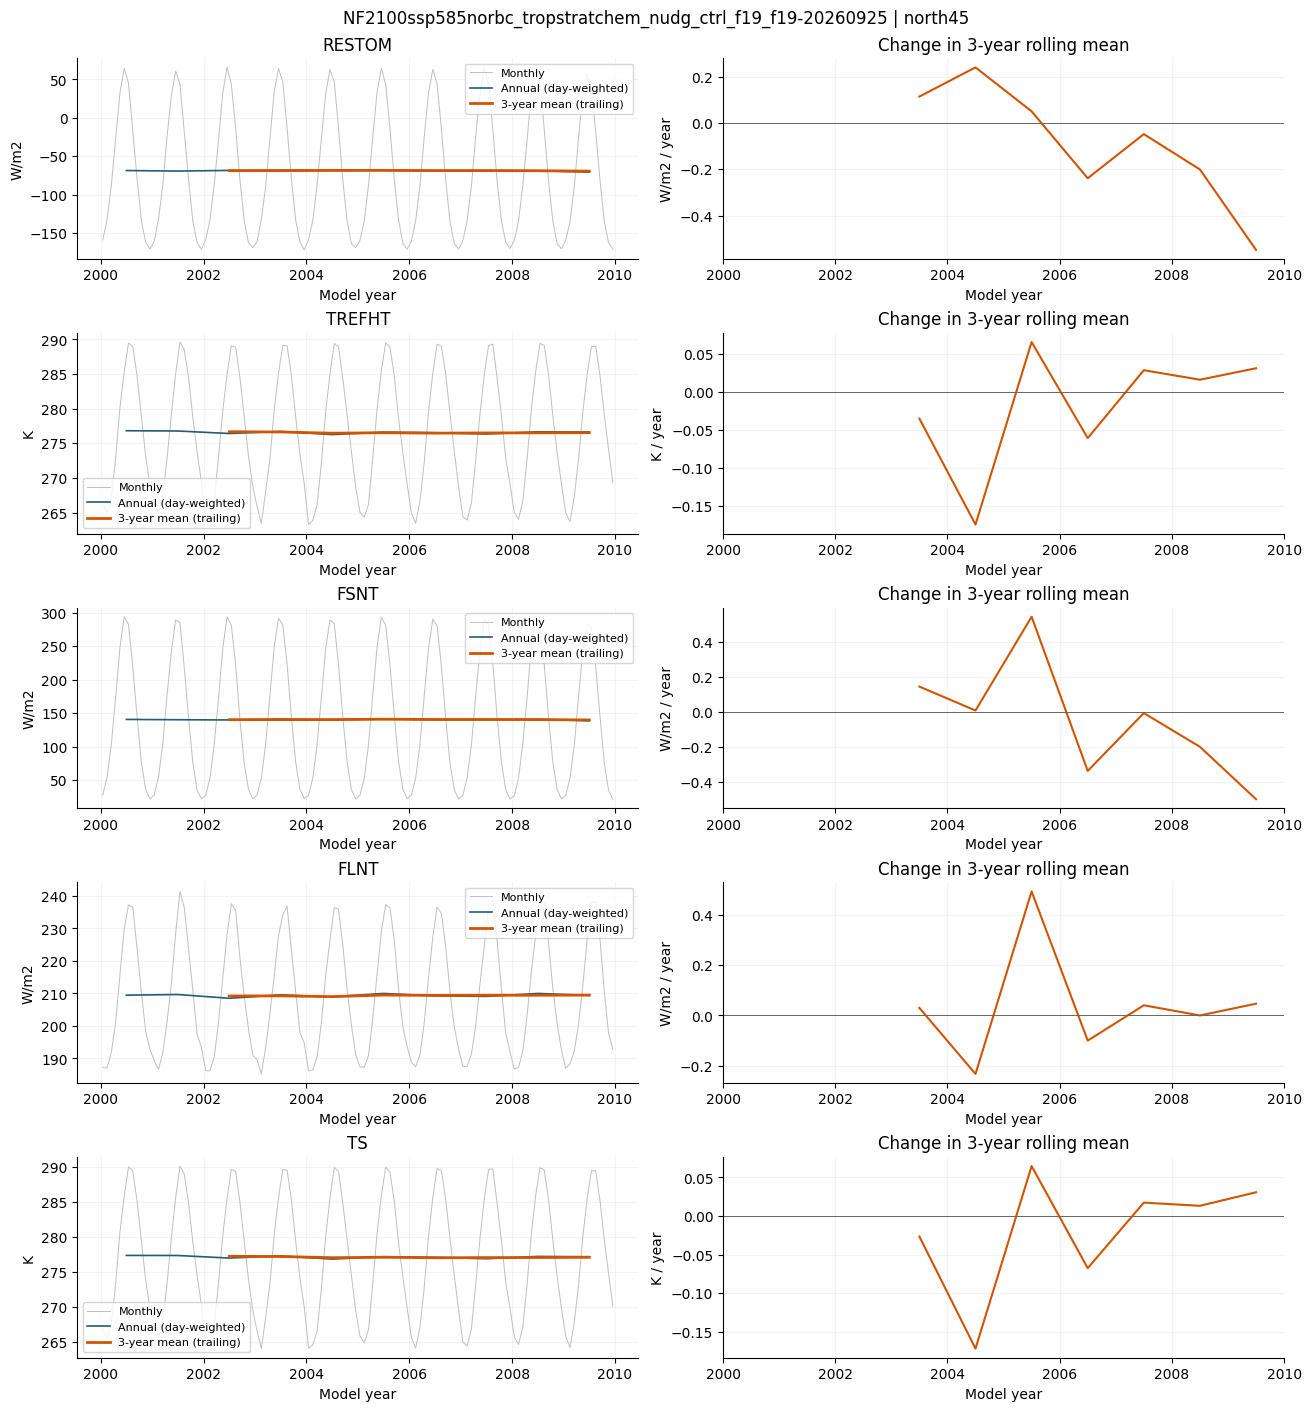

In [58]:
if RUN_CAM:
    directory = Path(OUTPUT / 'CAM'); directory.mkdir(parents=True, exist_ok=True)
    cam = eq.read_case(FILES['CAM'], 'CAM', regions=['north45'], #CAM_REGIONS, 
                       cache=cache, years=YEARS, timestamp=TIMESTAMP, gas_basis=GAS_BASIS, plev_hpa=PRESSURE_HPA)
    display(cam['audit'])
    #eq.save_result(cam, OUTPUT / 'CAM')
    for region in ['north45']: #CAM_REGIONS:
        fig, summary = eq.plot_timeseries(cam, eq.CAM_VARS, region, CASE, window=ROLL_YEARS)
        fig.savefig(OUTPUT / 'CAM' / f'{region}_timeseries.png', dpi=160)
        #summary.to_csv(OUTPUT / 'CAM' / f'{region}_summary.csv', index=False)
        #display(summary)
        plt.show()

## 6. Gas vertical profiles
Interpolate each column to fixed pressure before area averaging. No extrapolation below terrain or above the model. Annual plots require all 12 months and ≥95% monthly area coverage. Compare the final two 5-year blocks; inspect stratospheric drift even if total burdens are stable. Values retain native mixing-ratio units.

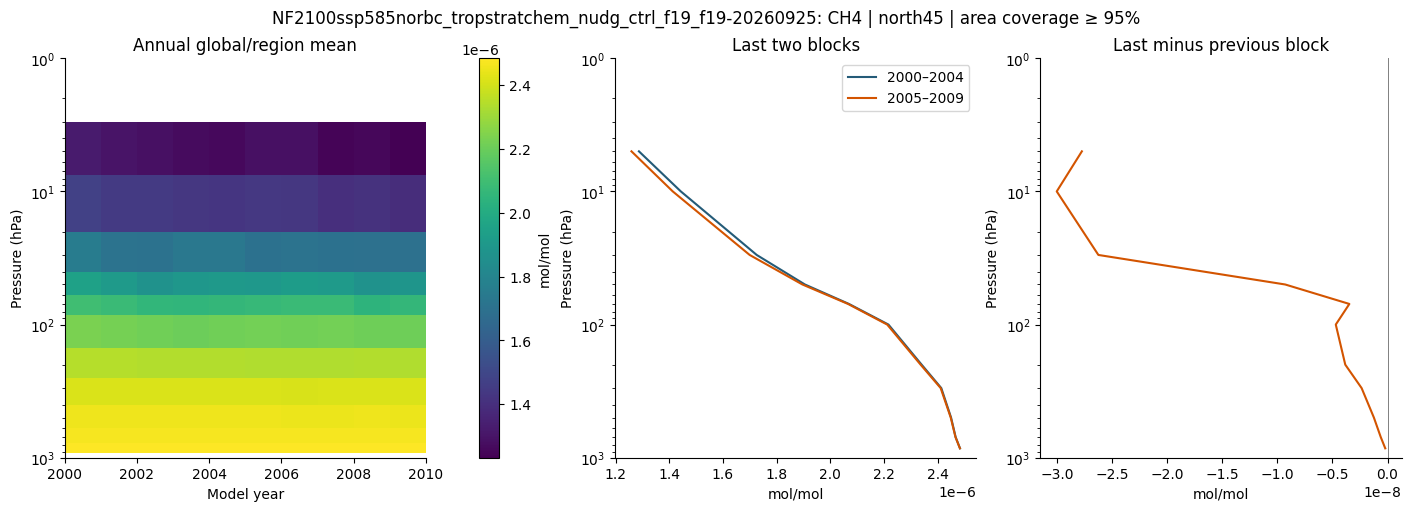

In [59]:
if RUN_CAM:
    PROFILE_REGIONS = ['north45']
    profiles = cam['profiles']

    for region in PROFILE_REGIONS:
        if profiles.empty or region not in profiles['region'].unique():
            print(f'{region}: no profiles stored; include it in CAM_REGIONS and rerun CAM processing.')
            continue

        gases = profiles.loc[profiles.region == region, 'gas'].unique()
        for gas in gases:
            fig = eq.plot_gas_profiles(cam, gas, region, block=5, title=CASE)
            if fig is not None:
                fig.savefig(OUTPUT / 'CAM' / f'{region}_{gas}_profiles.png', dpi=160)
                plt.show()

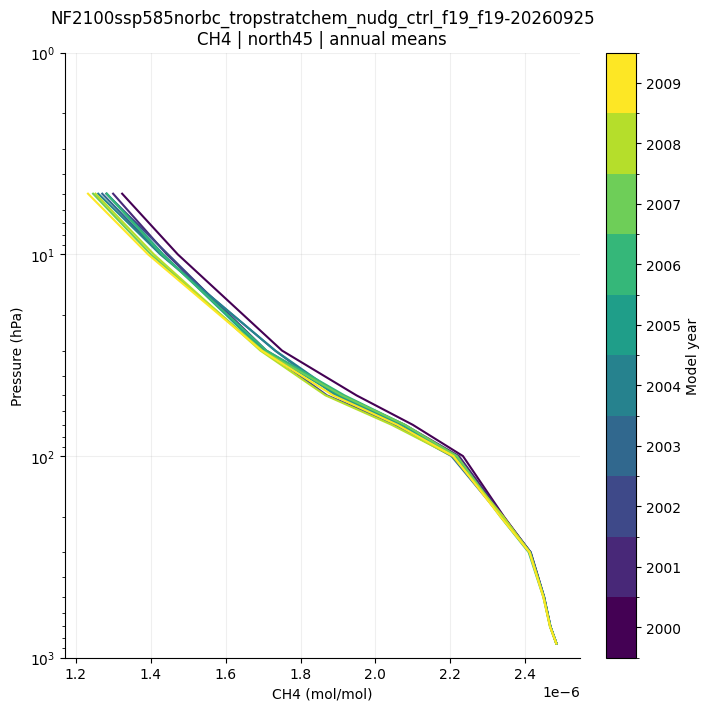

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm

if RUN_CAM:
    profiles = cam['profiles']

    if profiles.empty:
        print('No gas profiles were calculated.')
        display(cam['audit'])
    else:
        combinations = profiles[['region', 'gas']].drop_duplicates()

        for region, gas in combinations.itertuples(index=False, name=None):
            table = profiles[(profiles.region == region) & (profiles.gas == gas)].copy()
            table.loc[table.coverage < 0.95, 'value'] = np.nan
            annual = eq.annual_means(table, group=('region', 'gas', 'pressure_hpa'),
                                     values=['value'])
            data = annual.pivot(index='pressure_hpa', columns='year', values='value').sort_index()
            data = data.dropna(axis=1, how='all')

            if data.empty:
                print(f'{gas} | {region}: no usable complete annual profiles.')
                continue

            years = data.columns.to_numpy(dtype=int)
            boundaries = np.r_[years - 0.5, years[-1] + 0.5]
            cmap = plt.get_cmap('viridis', len(years))
            norm = BoundaryNorm(boundaries, cmap.N)

            fig, ax = plt.subplots(figsize=(7, 7), layout='constrained')
            for year in years:
                ax.plot(data[year], data.index, color=cmap(norm(year)), lw=1.5)

            ax.set_yscale('log')
            ax.set_ylim(data.index.max(), data.index.min())
            ax.set(xlabel=f'{gas} ({cam["units"].get(gas, "unknown")})',
                   ylabel='Pressure (hPa)', title=f'{CASE}\n{gas} | {region} | annual means')
            ax.grid(alpha=0.2)

            ticks = years[::max(1, int(np.ceil(len(years) / 15)))]
            fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax,
                         ticks=ticks, label='Model year', spacing='uniform')
            fig.savefig(OUTPUT / 'CAM' / f'{region}_{gas}_profiles_by_year.png', dpi=160)
            plt.show()

## 7. Gas column burdens and domain totals
Set `GAS_BASIS` after checking the tracer definitions, then rerun CAM calculations. Columns are kg m⁻²; totals are Tg over the selected domain (only `global` is a global burden). Monthly-mean products omit submonthly covariance. Missing or uncertain conversions appear in the audit, not as zero.

In [61]:
"""print('Current GAS_BASIS:', GAS_BASIS)

with xr.open_dataset(FILES['CAM'][0], decode_times=False) as ds:
    for name in ('CH4', 'Q'):
        if name in ds:
            print(f'\n{name}: dimensions={ds[name].dims}')
            print('Attributes:', ds[name].attrs)
        else:
            print(f'\n{name}: missing')
"""

"print('Current GAS_BASIS:', GAS_BASIS)\n\nwith xr.open_dataset(FILES['CAM'][0], decode_times=False) as ds:\n    for name in ('CH4', 'Q'):\n        if name in ds:\n            print(f'\n{name}: dimensions={ds[name].dims}')\n            print('Attributes:', ds[name].attrs)\n        else:\n            print(f'\n{name}: missing')\n"

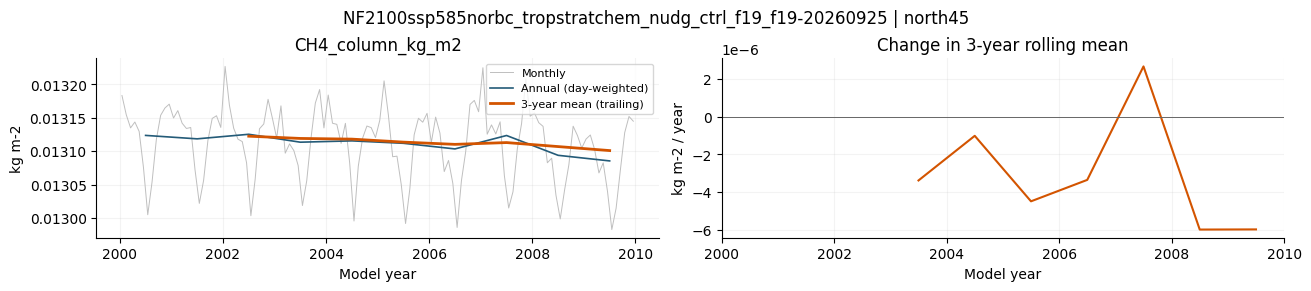

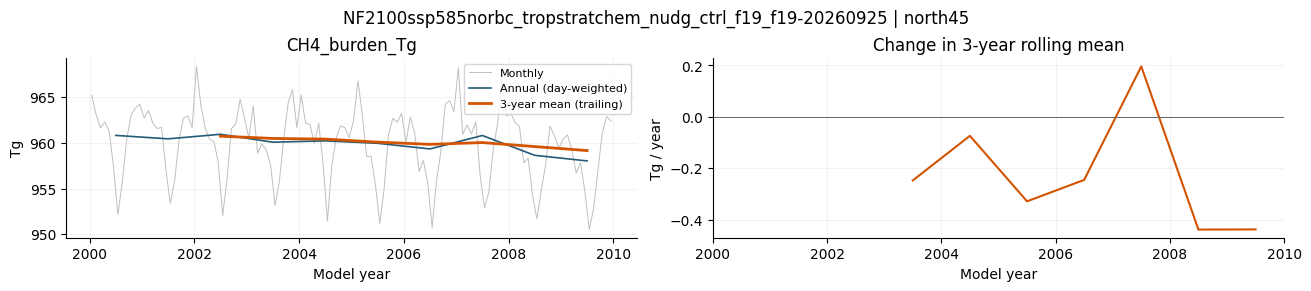

In [62]:
if RUN_CAM:
    for region in ['north45']:#CAM_REGIONS:
        burden_vars = [v for gas in eq.GASES for v in (gas + '_column_kg_m2', gas + '_burden_Tg') if v in cam['monthly']]
        if not burden_vars:
            print(region, ': no burdens calculated; inspect GAS_BASIS, units, Q and audit.')
            continue
        for suffix in ('_column_kg_m2', '_burden_Tg'):
            variables = [v for v in burden_vars if v.endswith(suffix)]
            fig, summary = eq.plot_timeseries(cam, variables, region, CASE, window=ROLL_YEARS)
            fig.savefig(OUTPUT / 'CAM' / f'{region}{suffix}.png', dpi=160)
            #summary.to_csv(OUTPUT / 'CAM' / f'{region}{suffix}_summary.csv', index=False)
            #display(summary)
            plt.show()

In [63]:
"""
if RUN_CAM:
    monthly = cam['monthly']
    gases = [name.removesuffix('_column_kg_m2') for name in monthly
             if name.endswith('_column_kg_m2')]

    if not gases:
        print('No gas burdens were calculated. Check GAS_BASIS and the audit:')
        display(cam['audit'])
    else:
        for region in monthly.region.unique():
            table = monthly[monthly.region == region]

            for gas in gases:
                column, total = f'{gas}_column_kg_m2', f'{gas}_burden_Tg'
                annual = eq.annual_means(table, values=[column, total]).sort_values('year')

                if not annual[[column, total]].notna().any().any():
                    print(f'{gas} | {region}: no valid complete annual burdens.')
                    continue

                fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')
                for ax, variable, label in zip(
                    axes, [column, total],
                    ['Mean column mass (kg m⁻²)', 'Domain total (Tg)']
                ):
                    ax.plot(annual.year, annual[variable], 'o-', ms=4)
                    ax.set(xlabel='Model year', ylabel=label)
                    ax.ticklabel_format(axis='x', style='plain', useOffset=False)
                    ax.grid(alpha=0.2)

                fig.suptitle(f'{CASE}\n{gas} | {region} | annual mean burden')
                fig.savefig(OUTPUT / 'CAM' / f'{region}_{gas}_annual_burden.png', dpi=160)
                plt.show()
"""

"\nif RUN_CAM:\n    monthly = cam['monthly']\n    gases = [name.removesuffix('_column_kg_m2') for name in monthly\n             if name.endswith('_column_kg_m2')]\n\n    if not gases:\n        print('No gas burdens were calculated. Check GAS_BASIS and the audit:')\n        display(cam['audit'])\n    else:\n        for region in monthly.region.unique():\n            table = monthly[monthly.region == region]\n\n            for gas in gases:\n                column, total = f'{gas}_column_kg_m2', f'{gas}_burden_Tg'\n                annual = eq.annual_means(table, values=[column, total]).sort_values('year')\n\n                if not annual[[column, total]].notna().any().any():\n                    print(f'{gas} | {region}: no valid complete annual burdens.')\n                    continue\n\n                fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')\n                for ax, variable, label in zip(\n                    axes, [column, total],\n                    ['

## Interpretation and limits

Use the plots and summary together: late drift, interannual variability, block differences and vertical structure. “Close to zero” needs a variable-specific physical tolerance and a comparison with the LCC signal, not a universal numerical cutoff. The reported OLS slope is descriptive and has no autocorrelation-adjusted uncertainty.

The 20-year rolling derivative is `(annual[y] − annual[y−20])/20`; a 20-year run gives one rolling mean but no derivative. Missing years break the sequence. Regional means can hide opposing cell trends, so this notebook does not establish that every cell equilibrated. 

- Nudged CTRL_PD evolution also reflects the imposed meteorology.

SF6/CFC115 and other long-lived gases require a forcing/boundary-condition check: a continuing imposed increase is not evidence of failed spinup. Prescribed 2-D or scalar gas fields cannot test 3-D chemical equilibration. For the BVOC study, these diagnostics do not by themselves establish equilibrium of SOA, ozone or cloud responses.

**Validation:** the package and all notebook code cells are tested in order with synthetic fixtures in plain Python (the local Jupyter kernel could not launch); actual Betzy files were unavailable during creation. Run all cells on Betzy and inspect audits, selected depths and coverage before drawing conclusions. See `README.md` for method references.